In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Cố định seed để dữ liệu tạo ra ngẫu nhiên nhưng giống nhau ở mỗi lần chạy
np.random.seed(42)

Câu 1

In [57]:
# 1. Tạo các mảng dữ liệu cơ bản
ma_kh = [f'KH{i:03d}' for i in range(1, 501)]

# Tạo Tuoi (float để có thể chứa NaN)
tuoi = np.random.randint(18, 71, size=500).astype(float)
tuoi_nan_idx = np.random.choice(500, 10, replace=False)
tuoi[tuoi_nan_idx] = np.nan

# Tạo ThuNhap và thêm 5 outliers
thu_nhap = np.random.uniform(5, 50, size=500)
outlier_idx = np.random.choice(500, 5, replace=False)
thu_nhap[outlier_idx] = np.random.uniform(150, 200, size=5) # Outliers lên tới 200 triệu

# Tạo GioiTinh (object để chứa NaN)
gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=500).astype(object)
gioi_tinh_nan_idx = np.random.choice(500, 15, replace=False)
gioi_tinh[gioi_tinh_nan_idx] = np.nan

# Tạo ThanhPho
thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=500)

# Tạo TongChiTieu tương quan nhẹ với ThuNhap
# (Thu nhập cao thường chi tiêu cao, cộng thêm nhiễu ngẫu nhiên)
tong_chi_tieu = thu_nhap * np.random.uniform(0.3, 0.7, size=500) + np.random.normal(0, 2, size=500)
# Đảm bảo chi tiêu không bị âm do nhiễu
tong_chi_tieu = np.clip(tong_chi_tieu, a_min=1, a_max=None)

# 2. Tạo DataFrame
df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

print("--- 5 dòng đầu của tập dữ liệu vừa khởi tạo ---")
display(df_khachhang.head())

--- 5 dòng đầu của tập dữ liệu vừa khởi tạo ---


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,19.865682,NaN,Hà Nội,8.691629
1,KH002,69.0,47.016132,Nam,TP.HCM,20.291056
2,KH003,46.0,5.339046,Nam,Hà Nội,6.146889
3,KH004,32.0,15.139976,Nữ,TP.HCM,11.940470
4,KH005,60.0,21.441057,Nam,Hà Nội,8.140173


Câu 2

In [58]:
# Kiểm tra số lượng giá trị khuyết
print("--- Số lượng giá trị khuyết trước khi xử lý ---")
print(df_khachhang.isnull().sum())

# Điền khuyết cột Tuoi bằng Trung vị (Median)
median_tuoi = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'] = df_khachhang['Tuoi'].fillna(median_tuoi)

# Điền khuyết cột GioiTinh bằng Yếu vị (Mode)
mode_gioitinh = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'] = df_khachhang['GioiTinh'].fillna(mode_gioitinh)

print("\n--- Số lượng giá trị khuyết sau khi xử lý ---")
print(df_khachhang.isnull().sum())

--- Số lượng giá trị khuyết trước khi xử lý ---
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64

--- Số lượng giá trị khuyết sau khi xử lý ---
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


Câu 3

In [59]:
# Tạo biến giả (dummy variables) cho cột ThanhPho
# Sử dụng dtype=int để hiển thị 0 và 1 thay vì True/False
thanhpho_dummies = pd.get_dummies(df_khachhang['ThanhPho'], prefix='ThanhPho', dtype=int)

# Gộp vào DataFrame gốc
df_khachhang = pd.concat([df_khachhang, thanhpho_dummies], axis=1)

print("--- Dữ liệu sau khi One-Hot Encoding cột ThanhPho ---")
display(df_khachhang.head())

--- Dữ liệu sau khi One-Hot Encoding cột ThanhPho ---


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,19.865682,Nữ,Hà Nội,8.691629,1,0,0
1,KH002,69.0,47.016132,Nam,TP.HCM,20.291056,0,1,0
2,KH003,46.0,5.339046,Nam,Hà Nội,6.146889,1,0,0
3,KH004,32.0,15.139976,Nữ,TP.HCM,11.940470,0,1,0
4,KH005,60.0,21.441057,Nam,Hà Nội,8.140173,1,0,0


Câu 4

In [60]:
# Tính Q1 (Phân vị thứ 25) và Q3 (Phân vị thứ 75)
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)

# Tính khoảng Tứ phân vị (IQR)
IQR = Q3 - Q1

# Xác định giới hạn
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc bỏ Outlier (Giữ lại các dòng nằm trong giới hạn an toàn)
shape_before = df_khachhang.shape
df_khachhang = df_khachhang[(df_khachhang['ThuNhap'] >= lower_bound) & (df_khachhang['ThuNhap'] <= upper_bound)]
shape_after = df_khachhang.shape

print(f"Giới hạn dưới: {lower_bound:.2f}, Giới hạn trên: {upper_bound:.2f}")
print(f"Số dòng trước khi lọc: {shape_before[0]}, Số dòng sau khi lọc: {shape_after[0]}")
print(f"Đã xóa {shape_before[0] - shape_after[0]} dòng dị biệt.")

Giới hạn dưới: -15.83, Giới hạn trên: 73.01
Số dòng trước khi lọc: 500, Số dòng sau khi lọc: 495
Đã xóa 5 dòng dị biệt.


Câu 5

In [61]:
# Khởi tạo MinMaxScaler
scaler = MinMaxScaler()

# fit_transform yêu cầu đầu vào là mảng 2D, do đó dùng df_khachhang[['TongChiTieu']]
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

print("--- Dữ liệu sau khi chuẩn hóa TongChiTieu về [0, 1] ---")
display(df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head())

--- Dữ liệu sau khi chuẩn hóa TongChiTieu về [0, 1] ---


,TongChiTieu,TongChiTieu_Scaled
0,8.691629,0.237277
1,20.291056,0.595106
2,6.146889,0.158775
3,11.940470,0.337500
4,8.140173,0.220266


Câu 6

In [62]:
# Lọc: Nữ, Tuổi > 30, sống ở Hà Nội
df_phu = df_khachhang[(df_khachhang['GioiTinh'] == 'Nữ') &
                      (df_khachhang['Tuoi'] > 30) &
                      (df_khachhang['ThanhPho'] == 'Hà Nội')]

print("--- 5 dòng đầu tiên của DataFrame phụ ---")
display(df_phu.head())

--- 5 dòng đầu tiên của DataFrame phụ ---


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
0,KH001,56.0,19.865682,Nữ,Hà Nội,8.691629,1,0,0,0.237277
16,KH017,41.0,30.919929,Nữ,Hà Nội,20.451264,1,0,0,0.600048
18,KH019,39.0,5.238500,Nữ,Hà Nội,3.756837,1,0,0,0.085045
19,KH020,70.0,48.878022,Nữ,Hà Nội,27.353295,1,0,0,0.812967
21,KH022,41.0,37.530324,Nữ,Hà Nội,17.630206,1,0,0,0.513022


Câu 7

In [63]:
# Gom nhóm theo ThanhPho và tính Mean, Sum của TongChiTieu
thongke_thanhpho = df_khachhang.groupby('ThanhPho')['TongChiTieu'].agg(['mean', 'sum']).reset_index()

# Đổi tên cột cho rõ ràng
thongke_thanhpho.rename(columns={'mean': 'Trung_Binh_Chi_Tieu', 'sum': 'Tong_Chi_Tieu'}, inplace=True)

print("--- Thống kê chi tiêu theo từng Thành phố ---")
display(thongke_thanhpho)

--- Thống kê chi tiêu theo từng Thành phố ---


,ThanhPho,Trung_Binh_Chi_Tieu,Tong_Chi_Tieu
0,Hà Nội,13.992811,2546.691616
1,TP.HCM,14.980764,2456.845293
2,Đà Nẵng,14.249704,2123.205856


Câu 8

In [64]:
# Định nghĩa các mốc chia (bins) và nhãn (labels)
bins = [17, 30, 45, 60, float('inf')] # Bắt đầu từ 17 để bao gồm số 18
labels = ['18-30', '31-45', '46-60', 'Trên 60']

# Cắt dữ liệu vào các khoảng
df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels)

print("--- Kiểm tra cột mới NhomTuoi ---")
display(df_khachhang[['Tuoi', 'NhomTuoi']].head(10))

--- Kiểm tra cột mới NhomTuoi ---


,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60
5,25.0,18-30
6,38.0,31-45
7,56.0,46-60
8,36.0,31-45
9,40.0,31-45


Câu 9

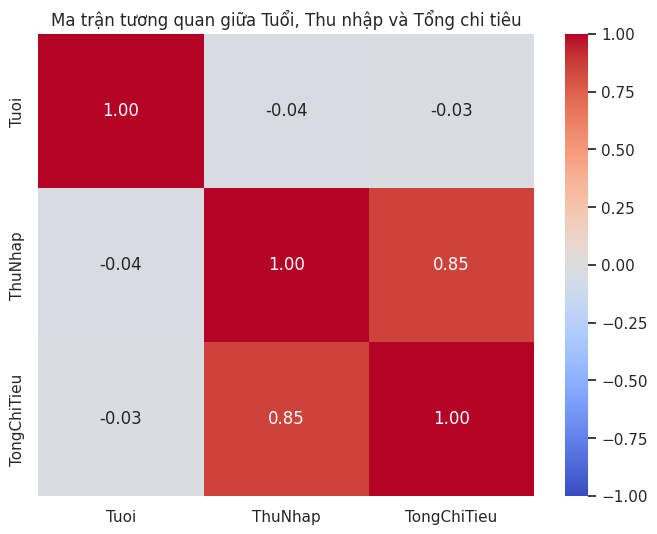

In [65]:
plt.figure(figsize=(8, 6))

# Lấy các cột số để tính tương quan
cols_to_corr = ['Tuoi', 'ThuNhap', 'TongChiTieu']
corr_matrix = df_khachhang[cols_to_corr].corr()

# Vẽ bản đồ nhiệt (Heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Ma trận tương quan giữa Tuổi, Thu nhập và Tổng chi tiêu')
plt.show()

Câu 10

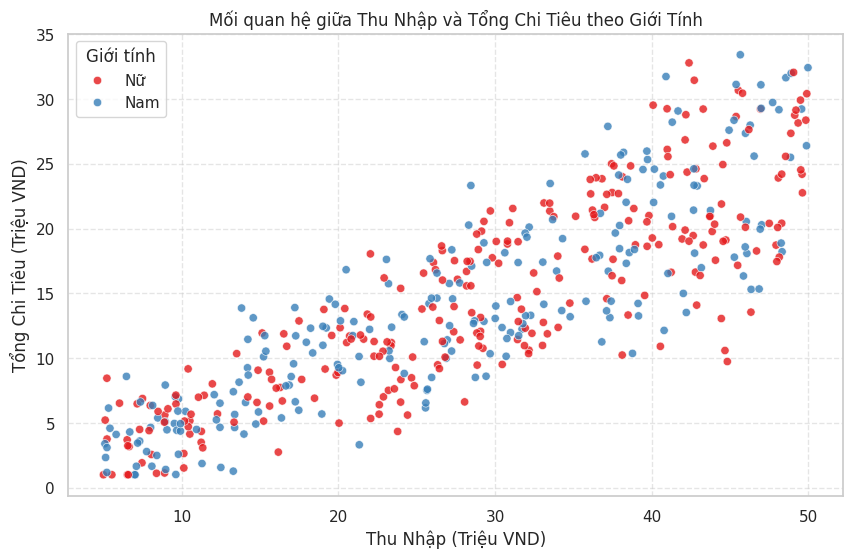

In [66]:
plt.figure(figsize=(10, 6))

# Vẽ Scatter plot với hue là GioiTinh
sns.scatterplot(
    data=df_khachhang,
    x='ThuNhap',
    y='TongChiTieu',
    hue='GioiTinh',
    palette='Set1',
    alpha=0.8
)

plt.title('Mối quan hệ giữa Thu Nhập và Tổng Chi Tiêu theo Giới Tính')
plt.xlabel('Thu Nhập (Triệu VND)')
plt.ylabel('Tổng Chi Tiêu (Triệu VND)')
plt.legend(title='Giới tính')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Câu 11

In [67]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist

# 1. Tải dữ liệu Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 2. Chuẩn hóa (scale) giá trị pixel về khoảng [0, 1]
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

# 3. Reshape dữ liệu: Thêm kênh màu (channel = 1 vì là ảnh xám)
# Kích thước chuẩn cho CNN là (số_lượng_ảnh, chiều_cao, chiều_rộng, số_kênh_màu)
X_train_reshaped = X_train_scaled.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test_scaled.reshape(-1, 28, 28, 1)

print("--- Yêu cầu 1: Hoàn tất Tiền xử lý ---")
print(f"Kích thước X_train sau khi reshape: {X_train_reshaped.shape}")
print(f"Kích thước X_test sau khi reshape: {X_test_reshaped.shape}")

--- Yêu cầu 1: Hoàn tất Tiền xử lý ---
Kích thước X_train sau khi reshape: (60000, 28, 28, 1)
Kích thước X_test sau khi reshape: (10000, 28, 28, 1)


In [68]:
# Khởi tạo mô hình Sequential
model = Sequential()

# Lớp Tích chập (Conv2D): 32 filters, kernel 3x3, hàm kích hoạt ReLU
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Lớp Pooling (MaxPooling2D): Mặc định là 2x2 để giảm kích thước ảnh
model.add(MaxPooling2D(pool_size=(2, 2)))

# Lớp Flatten: Duỗi dữ liệu thành mảng 1 chiều
model.add(Flatten())

# Lớp ẩn (Dense): 64 units, hàm kích hoạt ReLU
model.add(Dense(64, activation='relu'))

# Lớp đầu ra (Dense): 10 units (tương ứng 10 nhãn quần áo), hàm Softmax cho bài toán phân loại đa lớp
model.add(Dense(10, activation='softmax'))

print("--- Yêu cầu 2: Kiến trúc mô hình CNN ---")
model.summary()

--- Yêu cầu 2: Kiến trúc mô hình CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Biên dịch (Compile) mô hình
# Dùng loss='sparse_categorical_crossentropy' vì nhãn y là dạng số nguyên (0 đến 9), chưa One-Hot Encoding
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("--- Yêu cầu 3: Bắt đầu huấn luyện mô hình (5 Epochs) ---")
# Huấn luyện mô hình (Fit)
history = model.fit(X_train_reshaped, y_train, epochs=5, verbose=1)

--- Yêu cầu 3: Bắt đầu huấn luyện mô hình (5 Epochs) ---
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.8600 - loss: 0.3987
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9016 - loss: 0.2737
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9140 - loss: 0.2334
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9245 - loss: 0.2039
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9329 - loss: 0.1786


In [70]:
print("--- Yêu cầu 4: Đánh giá mô hình trên tập kiểm thử (Test Data) ---")

# Hàm evaluate trả về danh sách [độ mất mát, độ chính xác]
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Độ mất mát (Loss) trên tập test: {test_loss:.4f}")
print(f"Độ chính xác (Accuracy) trên tập test: {test_accuracy:.4f} ({(test_accuracy * 100):.2f}%)")

--- Yêu cầu 4: Đánh giá mô hình trên tập kiểm thử (Test Data) ---
Độ mất mát (Loss) trên tập test: 0.2574
Độ chính xác (Accuracy) trên tập test: 0.9116 (91.16%)
